# Customer Spending Behavior Prediction Project

This notebook supports a business analytics project that explores customer spending behavior using the Retail Analysis Large Dataset. It includes data cleaning, exploratory analysis, regression, classification, and K-Means clustering.

**Note:** Place the dataset file `new_retail_data.csv` inside the `data/` folder before running this notebook locally.


### **Milestone 1**

In [ ]:
# Libraries
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import matplotlib.dates as mdates

from sklearn.preprocessing import MinMaxScaler

In [ ]:
file_path = "../data/new_retail_data.csv"

df = pd.read_csv(file_path)
print(df.columns.tolist())

df.head()

['Transaction_ID', 'Customer_ID', 'Name', 'Email', 'Phone', 'Address', 'City', 'State', 'Zipcode', 'Country', 'Age', 'Gender', 'Income', 'Customer_Segment', 'Date', 'Year', 'Month', 'Time', 'Total_Purchases', 'Amount', 'Total_Amount', 'Product_Category', 'Product_Brand', 'Product_Type', 'Feedback', 'Shipping_Method', 'Payment_Method', 'Order_Status', 'Ratings', 'products']


,Transaction_ID,Customer_ID,Name,Email,Phone,Address,City,State,Zipcode,Country,...,Total_Amount,Product_Category,Product_Brand,Product_Type,Feedback,Shipping_Method,Payment_Method,Order_Status,Ratings,products
0,8691788.0,37249.0,Michelle Harrington,Ebony39@gmail.com,1.414787e+09,3959 Amanda Burgs,Dortmund,Berlin,77985.0,Germany,...,324.086270,Clothing,Nike,Shorts,Excellent,Same-Day,Debit Card,Shipped,5.0,Cycling shorts
1,2174773.0,69749.0,Kelsey Hill,Mark36@gmail.com,6.852900e+09,82072 Dawn Centers,Nottingham,England,99071.0,UK,...,806.707815,Electronics,Samsung,Tablet,Excellent,Standard,Credit Card,Processing,4.0,Lenovo Tab
2,6679610.0,30192.0,Scott Jensen,Shane85@gmail.com,8.362160e+09,4133 Young Canyon,Geelong,New South Wales,75929.0,Australia,...,1063.432799,Books,Penguin Books,Children's,Average,Same-Day,Credit Card,Processing,2.0,Sports equipment
3,7232460.0,62101.0,Joseph Miller,Mary34@gmail.com,2.776752e+09,8148 Thomas Creek Suite 100,Edmonton,Ontario,88420.0,Canada,...,2466.854021,Home Decor,Home Depot,Tools,Excellent,Standard,PayPal,Processing,4.0,Utility knife
4,4983775.0,27901.0,Debra Coleman,Charles30@gmail.com,9.098268e+09,5813 Lori Ports Suite 269,Bristol,England,48704.0,UK,...,248.553049,Grocery,Nestle,Chocolate,Bad,Standard,Cash,Shipped,1.0,Chocolate cookies


In [ ]:
print("Shape:", df.shape)
print(df.columns)

Shape: (302010, 30)
Index(['Transaction_ID', 'Customer_ID', 'Name', 'Email', 'Phone', 'Address',
       'City', 'State', 'Zipcode', 'Country', 'Age', 'Gender', 'Income',
       'Customer_Segment', 'Date', 'Year', 'Month', 'Time', 'Total_Purchases',
       'Amount', 'Total_Amount', 'Product_Category', 'Product_Brand',
       'Product_Type', 'Feedback', 'Shipping_Method', 'Payment_Method',
       'Order_Status', 'Ratings', 'products'],
      dtype='object')


In [ ]:
print("BASIC INFO")
print(df.info())


BASIC INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 302010 entries, 0 to 302009
Data columns (total 30 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Transaction_ID    301677 non-null  float64
 1   Customer_ID       301702 non-null  float64
 2   Name              301628 non-null  object 
 3   Email             301663 non-null  object 
 4   Phone             301648 non-null  float64
 5   Address           301695 non-null  object 
 6   City              301762 non-null  object 
 7   State             301729 non-null  object 
 8   Zipcode           301670 non-null  float64
 9   Country           301739 non-null  object 
 10  Age               301837 non-null  float64
 11  Gender            301693 non-null  object 
 12  Income            301720 non-null  object 
 13  Customer_Segment  301795 non-null  object 
 14  Date              301651 non-null  object 
 15  Year              301660 non-null  float64
 16  Month    

In [ ]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
Transaction_ID      333
Customer_ID         308
Name                382
Email               347
Phone               362
Address             315
City                248
State               281
Zipcode             340
Country             271
Age                 173
Gender              317
Income              290
Customer_Segment    215
Date                359
Year                350
Month               273
Time                350
Total_Purchases     361
Amount              357
Total_Amount        350
Product_Category    283
Product_Brand       281
Product_Type          0
Feedback            184
Shipping_Method     337
Payment_Method      297
Order_Status        235
Ratings             184
products              0
dtype: int64


In [ ]:
df = df.dropna(subset=['Transaction_ID', 'Customer_ID'])

These are unique identifiers, and missing values make the records unreliable and unusable for tracking transactions.

In [ ]:
df = df.drop(columns=['Name','Email','Phone','Address'])

These variables are not useful for analysis or prediction and contain a high number of missing values, which adds noise to the dataset.

In [ ]:
num_cols = ['Age', 'Total_Purchases', 'Amount', 'Total_Amount', 'Ratings', 'Year']
for col in num_cols:
  df[col] = df[col].fillna(df[col].median())

These are key numerical variables for analysis, and median imputation maintains data distribution without introducing bias.

In [ ]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

df = df.dropna(subset=['Date'])

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month_name()
df['Day'] = df['Date'].dt.day
df['Month_Year'] = df['Date'].dt.to_period('M').astype(str)

New time-related features were extracted from the Date column to enhance the dataset and support deeper analysis. The Year, Month, and Day features allow for easier grouping and aggregation of data, such as analyzing spending trends over time. The Month_Year feature combines both month and year into a single variable, which is especially useful for visualizing trends and ensuring proper chronological ordering in time series plots. These derived features make the dataset more informative and improve the ability to identify patterns in customer behavior.

In [ ]:
print("Duplicate rows:")
print(df.duplicated().sum())

Duplicate rows:
5


In [ ]:
df = df.drop_duplicates()

In [ ]:
# Rating bucket
df["Rating_Bucket"] = pd.cut(
    df["Ratings"],
    bins=[0, 2, 3, 4, 5],
    labels=["Low (1-2)", "Average (3)", "Good (4)", "Excellent (5)"],
    include_lowest=True
)

# Month-Year for trend analysis
df["Month_Year"] = df["Date"].dt.to_period("M").astype(str)

In [ ]:
# Here we are making a summary table that shows how many different values each column has.
print("UNIQUE VALUES PER COLUMN")

unique_counts = pd.DataFrame({
    "Column": df.columns,
    "Unique_Values": [df[col].nunique() for col in df.columns]
}).sort_values(by="Unique_Values", ascending=False)

display(unique_counts)

UNIQUE VALUES PER COLUMN


,Column,Unique_Values
16,Total_Amount,298316
15,Amount,298308
0,Transaction_ID,293830
4,Zipcode,93927
1,Customer_ID,86740
13,Time,83650
10,Date,366
25,products,318
2,City,130
3,State,54


In [ ]:
# This basically shows the feedback by customer segment
feedback_segment = pd.crosstab(df["Customer_Segment"], df["Feedback"])
display(feedback_segment)

Feedback,Average,Bad,Excellent,Good
Customer_Segment,,,,
New,18198,12758,32052,27814
Premium,11597,6002,25245,21314
Regular,32636,24372,43021,45597


In [ ]:
# This codeblock below shows the feedback by country
feedback_country = pd.crosstab(df["Country"], df["Feedback"])
display(feedback_country)

Feedback,Average,Bad,Excellent,Good
Country,,,,
Australia,8901,5402,17011,13850
Canada,8778,5491,16894,13953
Germany,10577,7397,18805,15846
UK,13258,9860,21382,18331
USA,20898,14970,26213,32734


In [ ]:
# The average rating by shipping method is shown in this code block
shipping_rating = df.groupby("Shipping_Method")["Ratings"].mean().sort_values(ascending=False)
display(shipping_rating)

,Ratings
Shipping_Method,
Same-Day,3.199472
Express,3.144108
Standard,3.141739


### **Milestone 2**

#### While age and geography have little impact on spending behavior, customers frequently shift their spending between product categories each month, showing that purchasing decisions are driven more by behavior and timing than by demographics.

The “exciting” discovery is that customer spending is driven more by purchasing behavior and product preference than by age or demographics, with premium customers showing significantly higher spending in key categories like electronics.

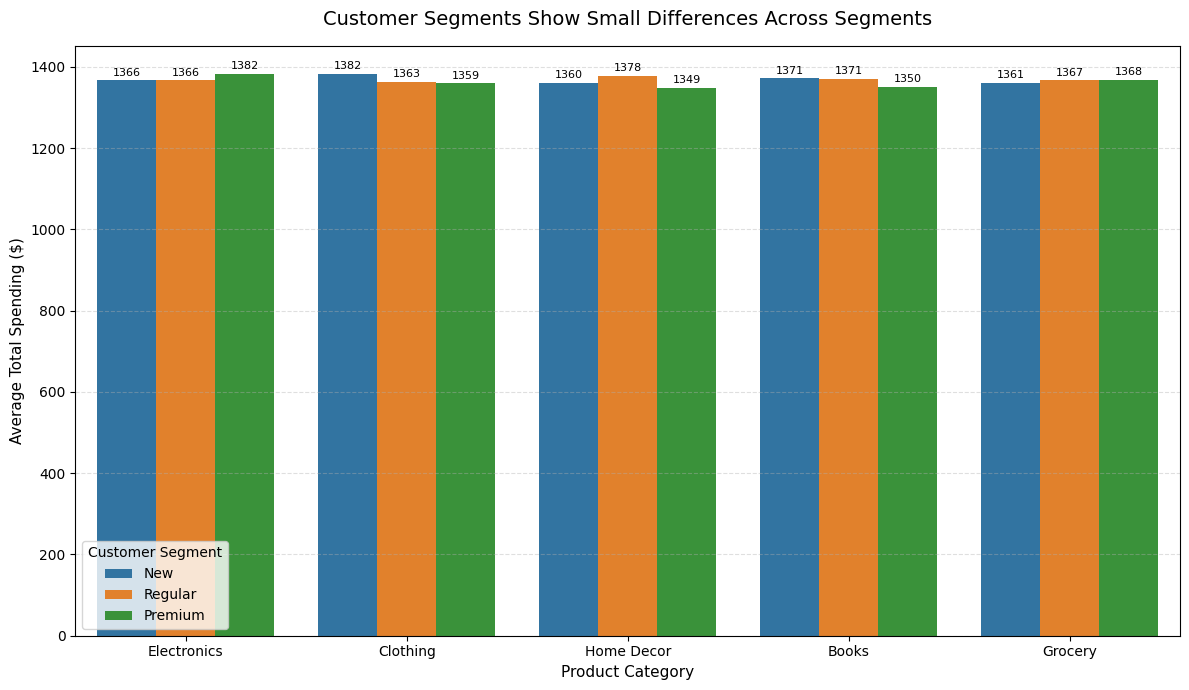

In [ ]:
# Spending Trends by Product Category Across Customer Segments
line_df = df.copy()

line_df['Date'] = pd.to_datetime(line_df['Date'], errors='coerce')

line_df = line_df[
    line_df['Date'].notna() &
    line_df['Customer_Segment'].notna() &
    line_df['Product_Category'].notna() &
    line_df['Total_Amount'].notna()
].copy()

line_df = line_df[
    (line_df['Customer_Segment'] != 'Unknown') &
    (line_df['Product_Category'] != 'Unknown')
].copy()

line_df['YearMonth'] = line_df['Date'].dt.to_period('M').dt.to_timestamp()

trend_df = (
    line_df.groupby(['YearMonth', 'Customer_Segment', 'Product_Category'])['Total_Amount']
    .mean()
    .reset_index()
)
trend_df = trend_df.sort_values('YearMonth')
seg_cat = (
    line_df.groupby(["Product_Category", "Customer_Segment"], as_index=False)["Total_Amount"]
      .mean()
)

category_order = (
    seg_cat.groupby("Product_Category")["Total_Amount"]
    .max()
    .sort_values(ascending=False)
    .index
)

segment_order = ["New", "Regular", "Premium"]

plt.figure(figsize=(12, 7))
ax = sns.barplot(
    data=seg_cat,
    x="Product_Category",
    y="Total_Amount",
    hue="Customer_Segment",
    order=category_order,
    hue_order=segment_order
)

plt.title("Customer Segments Show Small Differences Across Segments", fontsize=14, pad=15)
plt.xlabel("Product Category", fontsize=11)
plt.ylabel("Average Total Spending ($)", fontsize=11)
plt.legend(title="Customer Segment")
plt.grid(axis="y", linestyle="--", alpha=0.4)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", fontsize=8, padding=2)

plt.tight_layout()
plt.show()

## Data Interpretation & Observations

The chart shows that average spending across product categories is very similar for New, Regular, and Premium customers. While there are slight variations. For example, Premium customers spending slightly more in Electronics and New customers slightly higher in Clothing. These differences are minimal overall. No customer segment consistently dominates across all categories, and spending levels remain within a narrow range.

## Analytical Insights

The small differences between customer segments suggest that segmentation alone is not a strong predictor of spending behavior. Instead of clear spending gaps, the data indicates that all customer types exhibit similar purchasing patterns across categories. This implies that factors such as promotions, product demand, or timing may have a stronger influence than customer segment classification

## How This Helps Businesses

Better Marketing:
Businesses can create targeted offers for each group. For example, premium customers can be targeted with high-end product promotions, while regular customers can receive discounts when their spending drops.

Inventory Planning:
By understanding when certain categories increase in demand, businesses can prepare stock in advance and avoid running out of products.

Smarter Budget Use:
Instead of spending equally on all categories, companies can focus more on high-performing categories like electronics and reduce spending on weaker ones.

Pricing Strategy:
Since premium customers have uneven spending, businesses can introduce loyalty programs or subscriptions to keep their spending more consistent over time.

/tmp/ipykernel_1421/3260917394.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = line_df.groupby("Age_Group")["Total_Amount"].mean()


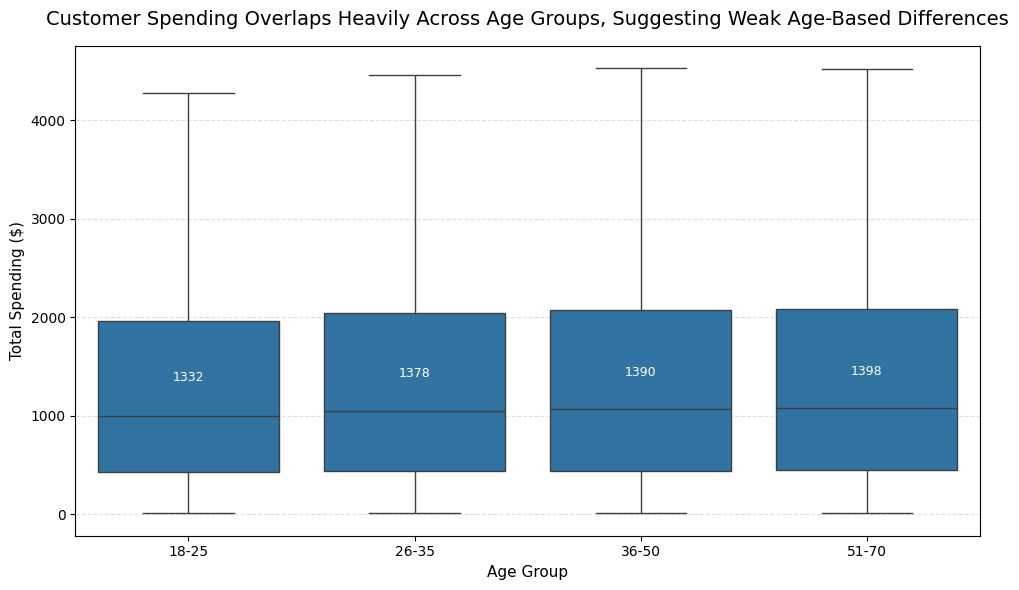

In [ ]:
# Create age groups
line_df["Age_Group"] = pd.cut(
    line_df["Age"],
    bins=[17, 25, 35, 50, 70],
    labels=["18-25", "26-35", "36-50", "51-70"]
)

plt.figure(figsize=(10, 6))
ax = sns.boxplot(
    data=line_df,
    x="Age_Group",
    y="Total_Amount",
    showfliers=False
)

# Calculate means
means = line_df.groupby("Age_Group")["Total_Amount"].mean()

# Add mean labels
for i, group in enumerate(means.index):
    ax.text(i, means[group] + 20,   # small offset so it doesn't overlap
            f"{means[group]:.0f}",
            ha='center', color='white', fontsize=9)

plt.title("Customer Spending Overlaps Heavily Across Age Groups, Suggesting Weak Age-Based Differences", fontsize=14, pad=15)
plt.xlabel("Age Group", fontsize=11)
plt.ylabel("Total Spending ($)", fontsize=11)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

## Data Interpretation & Observations

The boxplot shows that spending distributions overlap heavily across all age groups. The median and spread of spending are very similar, and the average values (around 1300–1400) are close across all groups. There are high and low spenders in every age category, indicating no clear trend between age and spending.

## Analytical Insights

The lack of noticeable differences across age groups suggests that age is not a strong factor in predicting customer spending. The overlapping distributions and similar averages reinforce that spending behavior is consistent regardless of demographic group.

## How This Helps Businesses

Focus on Behavior, Not Age:
Since age doesn’t predict spending, businesses should target customers based on actions like browsing or past purchases.

Use Similar Strategies Across Countries:
Spending patterns are similar across regions, so businesses can use consistent marketing strategies globally.

Improve Inventory Planning:
Businesses can prepare for demand spikes in certain categories and avoid overstocking others.

Better Promotions:
Targeted promotions can be used during low-spending periods to keep customers engaged.

Stabilize Spending:
Loyalty programs or subscriptions can help reduce big ups and downs in spending, especially for Premium customers.

### **Milestone 3**

In [ ]:
# Make a copy so the original dataframe stays unchanged
df_model = df.copy()

# Quick check
print(df_model.shape)
print(df_model.columns.tolist())

(301005, 29)
['Transaction_ID', 'Customer_ID', 'City', 'State', 'Zipcode', 'Country', 'Age', 'Gender', 'Income', 'Customer_Segment', 'Date', 'Year', 'Month', 'Time', 'Total_Purchases', 'Amount', 'Total_Amount', 'Product_Category', 'Product_Brand', 'Product_Type', 'Feedback', 'Shipping_Method', 'Payment_Method', 'Order_Status', 'Ratings', 'products', 'Day', 'Month_Year', 'Rating_Bucket']


In [ ]:
# Remove rows with missing target just in case
df_model = df_model.dropna(subset=['Total_Amount'])

# Define target
y = df_model['Total_Amount']

# Features to include
selected_features = [
    'Total_Purchases',
    'Age',
    'Income',
    'Customer_Segment',
    'Product_Category',
    'Product_Type',
    'Payment_Method',
    'Ratings'
]

# Create feature set
X = df_model[selected_features].copy()

print("Feature columns:")
print(X.columns.tolist())

Feature columns:
['Total_Purchases', 'Age', 'Income', 'Customer_Segment', 'Product_Category', 'Product_Type', 'Payment_Method', 'Ratings']


In [ ]:
# Separate numeric and categorical columns
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['Total_Purchases', 'Age', 'Ratings']
Categorical features: ['Income', 'Customer_Segment', 'Product_Category', 'Product_Type', 'Payment_Method']


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (240804, 8)
X_test shape: (60201, 8)
y_train shape: (240804,)
y_test shape: (60201,)


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Numeric preprocessing
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine preprocessing
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

Removed non-informative and high-cardinality features such as Customer_ID and Zipcode as they do not provide meaningful predictive value and may introduce noise or overfitting. Temporal variables like Date and Time were also excluded in their raw format since they require feature engineering (e.g., extracting month or day patterns) to be useful in regression models.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Model 1: Linear Regression
lr_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

# Model 2: Random Forest Regressor
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
    n_estimators=30,
    max_depth=10,
    random_state=42,
    n_jobs=-1
    ))
])

In [ ]:
# Fit models
lr_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

print("Both models trained successfully.")

Both models trained successfully.


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Predictions
y_pred_lr = lr_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

# Metrics function
def evaluate_model(y_true, y_pred, model_name):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    print(f"--- {model_name} ---")
    print(f"R²   : {r2:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print()

evaluate_model(y_test, y_pred_lr, "Linear Regression")
evaluate_model(y_test, y_pred_rf, "Random Forest Regressor")

--- Linear Regression ---
R²   : 0.4194
MAE  : 653.2168
RMSE : 857.8116

--- Random Forest Regressor ---
R²   : 0.4179
MAE  : 653.7352
RMSE : 858.8969



The Linear Regression model achieved an R² of approximately 0.419, while the Random Forest Regressor produced a similar R² of 0.418. This indicates that both models are able to explain around 42% of the variance in customer spending (Total_Amount).

The models exhibit moderate predictive power, with more than half of the variance (approximately 58%) remaining unexplained. This indicates that additional factors—such as product preferences, timing, or external influences—may play a substantial role in determining customer spending behavior.

Furthermore, the nearly identical performance between Linear Regression and Random Forest suggests that the relationship between the predictors and the target variable is largely linear, and that more complex models do not provide additional benefit.

In [ ]:
from sklearn.model_selection import cross_validate, KFold

# Use a smaller sample from training data for cross-validation
X_train_cv = X_train.sample(n=10000, random_state=42)
y_train_cv = y_train.loc[X_train_cv.index]

# 5-fold for Linear Regression
kf_lr = KFold(n_splits=5, shuffle=True, random_state=42)

lr_cv = cross_validate(
    lr_model,
    X_train_cv,
    y_train_cv,
    cv=kf_lr,
    scoring={
        'r2': 'r2',
        'rmse': 'neg_root_mean_squared_error'
    },
    n_jobs=-1
)

print("Linear Regression CV Results")
print("Mean R²   :", lr_cv['test_r2'].mean())
print("Std R²    :", lr_cv['test_r2'].std())
print("Mean RMSE :", -lr_cv['test_rmse'].mean())
print("Std RMSE  :", lr_cv['test_rmse'].std())
print()

Linear Regression CV Results
Mean R²   : 0.41633449700263114
Std R²    : 0.01701450297754057
Mean RMSE : 860.6547190986848
Std RMSE  : 10.526255292708646



In [ ]:
kf_rf = KFold(n_splits=3, shuffle=True, random_state=42)

rf_cv = cross_validate(
    rf_model,
    X_train_cv,
    y_train_cv,
    cv=kf_rf,
    scoring={
        'r2': 'r2',
        'rmse': 'neg_root_mean_squared_error'
    },
    n_jobs=-1
)

print("Random Forest CV Results")
print("Mean R²   :", rf_cv['test_r2'].mean())
print("Std R²    :", rf_cv['test_r2'].std())
print("Mean RMSE :", -rf_cv['test_rmse'].mean())
print("Std RMSE  :", rf_cv['test_rmse'].std())

Random Forest CV Results
Mean R²   : 0.3986839511500901
Std R²    : 0.01056356641610083
Mean RMSE : 873.8788131931756
Std RMSE  : 6.500313129832448


Even after applying cross-validation, both models consistently perform poorly, confirming that the lack of predictive power is not due to overfitting or random variation, but rather due to weak relationships between the features and the target variable.


Overall, cross-validation confirms that the poor performance observed earlier is not due to overfitting or randomness, but rather due to weak relationships between the available features and the target variable.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest Regressor'],
    'Test R²': [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_rf)
    ],
    'Test MAE': [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_rf)
    ],
    'Test RMSE': [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf))
    ],
    'CV Mean R²': [
        lr_cv['test_r2'].mean(),
        rf_cv['test_r2'].mean()
    ],
    'CV Std R²': [
        lr_cv['test_r2'].std(),
        rf_cv['test_r2'].std()
    ]

})

results

,Model,Test R²,Test MAE,Test RMSE,CV Mean R²,CV Std R²
0,Linear Regression,0.419362,653.216819,857.811622,0.416334,0.017015
1,Random Forest Regressor,0.417891,653.735223,858.896936,0.398684,0.010564


While the initial approach focused on predicting customer spending using regression models, the results demonstrated moderate predictive performance, even after applying cross-validation. This indicates that the available features do not strongly explain spending behavior.

However, the primary objective of the project is not only prediction but understanding the key factors and patterns that drive customer behavior. Therefore, the analysis was extended to classification and clustering techniques to identify meaningful customer segments.

# **CLASSIFICATION**

In [ ]:
df["Total_Amount"].describe()

,Total_Amount
count,301005.000000
mean,1367.430853
std,1128.323696
min,10.003750
25%,439.428886
50%,1041.205562
75%,2028.012605
max,4999.625796


In [ ]:
# 1. Change target into classes

# Define bins based on quartiles
bins = [0, 439, 2027, float('inf')]
labels = ["Low", "Medium", "High"]

df_model["Spending_Class"] = pd.cut(
    df_model["Total_Amount"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Define target
y = df_model["Spending_Class"]

# Define features to INCLUDE
selected_features = [
    'Total_Purchases',
    'Age',
    'Income',
    'Customer_Segment',
    'Product_Category',
    'Product_Type',
    'Payment_Method',
    'Ratings'
]

# Create feature set
X = df_model[selected_features].copy()

# Rebuild feature lists
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

print(df_model["Spending_Class"].value_counts())
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Spending_Class
Medium    150527
High       75311
Low        75167
Name: count, dtype: int64
X shape: (301005, 8)
y shape: (301005,)
Numeric features: ['Total_Purchases', 'Age', 'Ratings']
Categorical features: ['Income', 'Customer_Segment', 'Product_Category', 'Product_Type', 'Payment_Method']


The distribution of spending class is not balanced, as the majority of customers fall under Medium class. To address this, we will set the class_weight into balanced when building the models later.

In [ ]:
# 2. Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (240804, 8)
X_test shape: (60201, 8)
y_train shape: (240804,)
y_test shape: (60201,)


In [ ]:
# 3. Preprocessing pipeline

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [ ]:
# 4. Build classification models

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

log_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42))
])

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(class_weight="balanced",
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ))
])

log_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

print("Both classification models trained successfully.")

Both classification models trained successfully.


In [ ]:
# 5. Test-set evaluation

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

y_pred_log = log_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

def evaluate_classifier(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="weighted")
    rec = recall_score(y_true, y_pred, average="weighted")
    f1 = f1_score(y_true, y_pred, average="weighted")

    print(f"\n--- {model_name} ---")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

evaluate_classifier(y_test, y_pred_log, "Logistic Regression")
evaluate_classifier(y_test, y_pred_rf, "Random Forest Classifier")


--- Logistic Regression ---
Accuracy : 0.5202
Precision: 0.5557
Recall   : 0.5202
F1 Score : 0.4905

Classification Report:
              precision    recall  f1-score   support

        High       0.52      0.80      0.63     15062
         Low       0.46      0.73      0.57     15033
      Medium       0.62      0.28      0.38     30106

    accuracy                           0.52     60201
   macro avg       0.53      0.60      0.53     60201
weighted avg       0.56      0.52      0.49     60201


--- Random Forest Classifier ---
Accuracy : 0.4519
Precision: 0.5962
Recall   : 0.4519
F1 Score : 0.3291

Classification Report:
              precision    recall  f1-score   support

        High       0.43      1.00      0.60     15062
         Low       0.46      0.73      0.56     15033
      Medium       0.75      0.04      0.07     30106

    accuracy                           0.45     60201
   macro avg       0.55      0.59      0.41     60201
weighted avg       0.60      0.45     

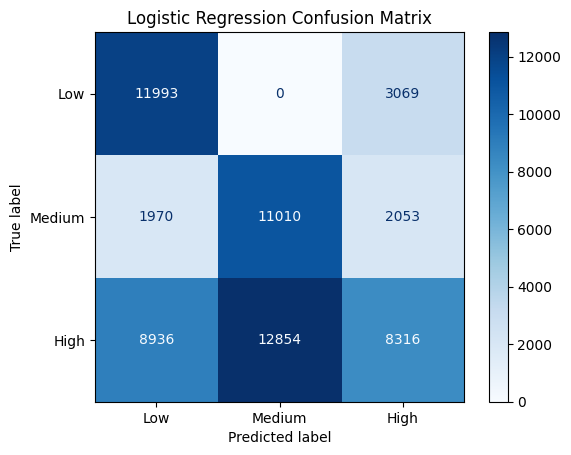

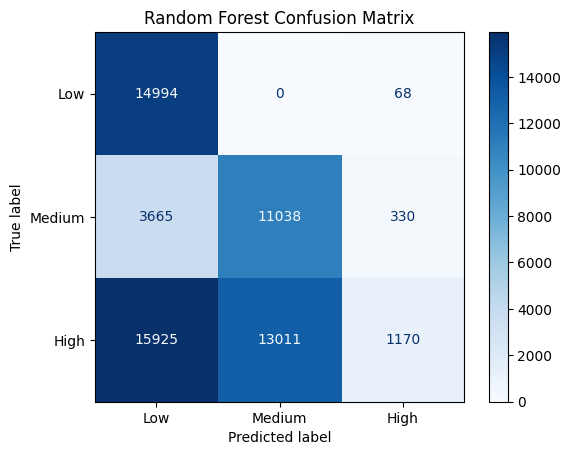

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create confusion matrix
log_cm = confusion_matrix(y_test, y_pred_log)
rf_cm = confusion_matrix(y_test, y_pred_rf)

# Display it
# Logistic Regression
log_disp = ConfusionMatrixDisplay(confusion_matrix=log_cm, display_labels=["Low", "Medium", "High"])
log_disp.plot(cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")

# Random Forest
rf_disp = ConfusionMatrixDisplay(confusion_matrix=rf_cm, display_labels=["Low", "Medium", "High"])
rf_disp.plot(cmap="Blues")
plt.title("Random Forest Confusion Matrix")

plt.show()

The Logistic Regression model achieved an accuracy of approximately 52%, representing a substantial improvement compared to earlier results prior to the inclusion of Total_Purchases.

The model performs well in identifying high-spending customers, achieving a recall of 80%, and shows reasonable performance for low-spending customers with a recall of 73%. However, performance for the medium-spending group is significantly weaker, with a recall of only 28%, indicating that the model struggles to distinguish customers in the middle range.

The Random Forest Classifier achieved an accuracy of approximately 45%, which is lower than the Logistic Regression model, indicating weaker overall performance.

While the model achieved a recall of 100% for high-spending customers, this result is misleading, as the confusion matrix shows that the model frequently overpredicts the high-spending class. As a result, many customers from other categories are incorrectly classified as high spenders.

The model performs moderately for low-spending customers, with a recall of 73%, but performs extremely poorly for medium-spending customers, with a recall of only 4%, indicating a near-complete failure to identify this group.

These results suggest that the Random Forest model is heavily biased toward predicting extreme classes and is unable to effectively capture balanced customer segments.

In [ ]:
# 6. Cross-validation

from sklearn.model_selection import cross_validate, StratifiedKFold

X_train_cv = X_train.sample(n=10000, random_state=42)
y_train_cv = y_train.loc[X_train_cv.index]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

log_cv = cross_validate(
    log_model,
    X_train_cv,
    y_train_cv,
    cv=skf,
    scoring=["accuracy", "precision_weighted", "recall_weighted", "f1_weighted"],
    n_jobs=-1
)

rf_cv = cross_validate(
    rf_model,
    X_train_cv,
    y_train_cv,
    cv=skf,
    scoring=["accuracy", "precision_weighted", "recall_weighted", "f1_weighted"],
    n_jobs=-1
)

print("\nLogistic Regression CV Results")
print("Mean Accuracy :", log_cv["test_accuracy"].mean())
print("Mean Precision:", log_cv["test_precision_weighted"].mean())
print("Mean Recall   :", log_cv["test_recall_weighted"].mean())
print("Mean F1       :", log_cv["test_f1_weighted"].mean())

print("\nRandom Forest CV Results")
print("Mean Accuracy :", rf_cv["test_accuracy"].mean())
print("Mean Precision:", rf_cv["test_precision_weighted"].mean())
print("Mean Recall   :", rf_cv["test_recall_weighted"].mean())
print("Mean F1       :", rf_cv["test_f1_weighted"].mean())


Logistic Regression CV Results
Mean Accuracy : 0.5285
Mean Precision: 0.562041202608117
Mean Recall   : 0.5285
Mean F1       : 0.5105652869750545

Random Forest CV Results
Mean Accuracy : 0.5418000000000001
Mean Precision: 0.6005834793362961
Mean Recall   : 0.5418000000000001
Mean F1       : 0.5203806355594478


In [ ]:
# 7. Final comparison table

import pandas as pd

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest Classifier"],
    "Test Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Test Precision": [
        precision_score(y_test, y_pred_log, average="weighted"),
        precision_score(y_test, y_pred_rf, average="weighted")
    ],
    "Test Recall": [
        recall_score(y_test, y_pred_log, average="weighted"),
        recall_score(y_test, y_pred_rf, average="weighted")
    ],
    "Test F1": [
        f1_score(y_test, y_pred_log, average="weighted"),
        f1_score(y_test, y_pred_rf, average="weighted")
    ],
    "CV Mean Accuracy": [
        log_cv["test_accuracy"].mean(),
        rf_cv["test_accuracy"].mean()
    ]
})

print(results)

                      Model  Test Accuracy  Test Precision  Test Recall  \
0       Logistic Regression       0.520241        0.555722     0.520241   
1  Random Forest Classifier       0.451853        0.596241     0.451853   

    Test F1  CV Mean Accuracy  
0  0.490468            0.5285  
1  0.329127            0.5418  


Logistic Regression achieved about 52% accuracy and performed well in identifying high and low spenders. However, it struggled to correctly classify medium spenders, indicating that customer spending exists more as a continuous pattern rather than distinct categories.

On the other hand, the Random Forest model performed worse overall and showed strong bias toward predicting high-spending customers. It almost completely failed to identify medium spenders.

# **CLUSTERING**

These findings indicate that the available features do not have strong predictive power for estimating or classifying customer spending. We do not need to stick with supervised learning since we're not focusing on predicting how much customers spend, rather identifying the factors of their spending behavior, since that is our business problem. Therefore, rather than forcing a weak predictive model, the analysis was shifted toward an unsupervised learning approach.

k=3, inertia=682708.60
k=4, inertia=573292.20
k=5, inertia=502347.53
k=6, inertia=448497.21
k=7, inertia=397288.60
k=8, inertia=358445.89
k=9, inertia=331418.62
k=10, inertia=307914.86
k=11, inertia=288633.89
k=12, inertia=273039.11
k=13, inertia=262038.00
k=14, inertia=251631.46
k=15, inertia=242363.49
k=16, inertia=232750.07
k=17, inertia=224769.88
k=18, inertia=216500.43
k=19, inertia=210127.67
k=20, inertia=203919.84


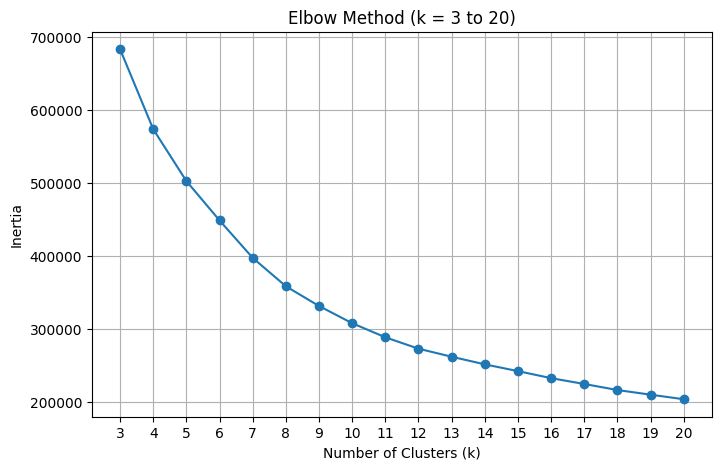

Chosen k: 8


,Age,Total_Purchases,Total_Amount,Ratings
Cluster,,,,
0,24.716121,2.812077,600.744242,1.557291
1,33.130076,8.955572,3635.357724,3.163470
2,26.051029,7.019903,1475.874596,3.928465
3,53.050406,7.759193,1970.075193,4.201685
4,51.550804,2.997840,622.240034,4.260196
5,25.343714,2.651972,566.748285,3.897215
6,55.638090,4.980607,1049.515943,1.882553
7,25.031714,7.493085,1752.066039,1.520533


The elbow is around 8-10: we will use 8.


In [ ]:
# MODELLING: K-MEANS CLUSTERING

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

cluster_df = df.copy()

# Choose customer behavior features
cluster_features = [
    'Age',
    'Total_Purchases',
    'Total_Amount',
    'Ratings'
]

# Keep only available columns
cluster_features = [col for col in cluster_features if col in cluster_df.columns]

cluster_data = cluster_df[cluster_features].copy()

# Fill missing values
for col in cluster_features:
    cluster_data[col] = cluster_data[col].fillna(cluster_data[col].median())

# Scale data
scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_data)

# Elbow Method: compute inertia for k = 3 to 20
inertias = []
k_values = range(3, 21)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(cluster_scaled)
    inertias.append(kmeans.inertia_)
    print(f"k={k}, inertia={kmeans.inertia_:.2f}")

# Plot elbow curve
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method (k = 3 to 20)')
plt.xticks(list(k_values))
plt.grid(True)
plt.show()

best_k = 8
print("Chosen k:", best_k)

# Fit final model
final_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_df['Cluster'] = final_kmeans.fit_predict(cluster_scaled)

# View cluster summary
cluster_summary = cluster_df.groupby('Cluster')[cluster_features].mean()
display(cluster_summary)

print("The elbow is around 8-10: we will use 8.")

The Elbow Method was used to determine the optimal number of clusters. The inertia decreases sharply up to approximately k = 8, after which the rate of improvement slows significantly. This indicates diminishing returns in reducing within-cluster variance. Therefore, k = 8 was selected as the optimal number of clusters.

In [ ]:
cluster_features = ['Age', 'Total_Amount']
from sklearn.preprocessing import StandardScaler

# Select features and drop missing values
X_cluster = df[cluster_features].dropna()

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=8, random_state=42)

clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels back to dataframe
df_clustered = X_cluster.copy()
df_clustered['Cluster'] = clusters

cluster_summary = df_clustered.groupby('Cluster').agg({
    'Age': ['mean', 'min', 'max'],
    'Total_Amount': ['mean', 'min', 'max', 'count']
})

cluster_summary

Age             Total_Amount                                 
              mean   min   max         mean          min          max  count
Cluster                                                                     
0        48.684043  36.0  70.0  1964.584667  1228.619330  2928.871330  28966
1        22.082391  18.0  29.0   526.153750    10.003750  1228.913315  78261
2        24.101515  18.0  36.0  1844.677108  1153.038229  2681.957001  51362
3        63.340810  54.0  70.0   806.754140    10.133500  2365.461225  27508
4        53.799121  40.0  70.0  3484.556039  2384.554376  4999.171428  17289
5        25.463629  19.0  39.0  3465.421445  2608.156064  4999.625796  27563
6        47.587108  41.0  57.0   531.984135    10.056353  1274.064433  39078
7        34.516463  28.0  42.0   646.612782    10.226839  1589.486609  30978

K-Means clustering with k = 8 was applied to segment customers based on age and total spending behavior. While eight clusters were identified, they can be consolidated into broader customer segments to provide more meaningful and actionable insights.

High-value customers are in clusters 1, 3, and 4, having their average spending of over $2000-$3000. These clusters represent the most valuable customers, contributing the highest revenue. Interestingly, high spending is observed across different age groups, indicating that age alone does not determine purchasing power.

Mid-value customers are in clusters 6 and 7, with average spending of $1300-$1900. These customers show moderate purchasing behavior and represent strong growth potential. With the right incentives, they could be converted into high-value customers.

Low-value customers are in clusters 0, 2, and 5, with average spending of only less than $1000. This segment consists of customers with low engagement and minimal spending. The presence of both young and older customers again highlights that demographic factors alone do not explain purchasing behavior.

The results suggest that traditional predictive modeling approaches are not effective for this dataset due to weak relationships between features and spending behavior. However, clustering successfully uncovers meaningful customer segments, providing valuable insights for business decision-making. These segments enable companies to design targeted marketing strategies, improve customer engagement, and optimize revenue generation.

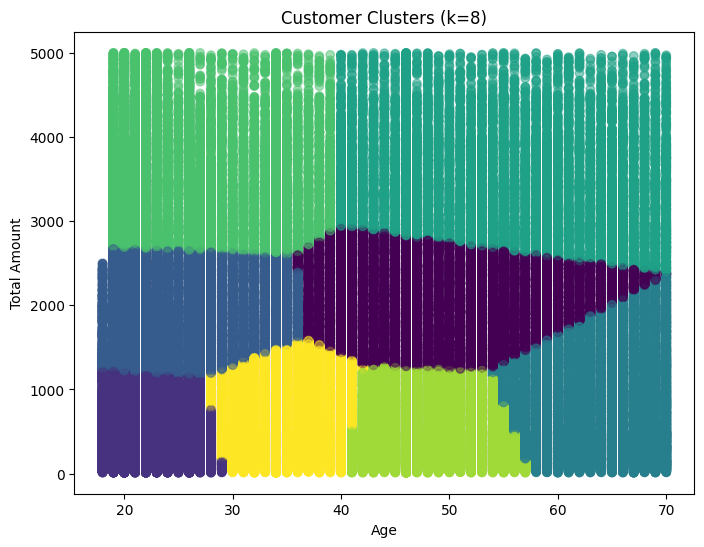

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(
    df_clustered['Age'],
    df_clustered['Total_Amount'],
    c=df_clustered['Cluster'],
    alpha=0.5
)

plt.xlabel("Age")
plt.ylabel("Total Amount")
plt.title("Customer Clusters (k=8)")
plt.show()

The scatter plot illustrates the clustering results by mapping customer age against total spending, with each color representing a different cluster. This visualization provides a clear view of how customers are distributed across different spending levels and age groups. There is no clear upward or downward trend between age and total spending. Customers across all age groups appear in both low and high spending clusters.

The visualization reinforces that customer spending behavior is not strongly influenced by age, but instead forms distinct spending-based segments. This supports the earlier conclusion that predictive models perform poorly because demographic features alone do not capture the complexity of customer behavior.

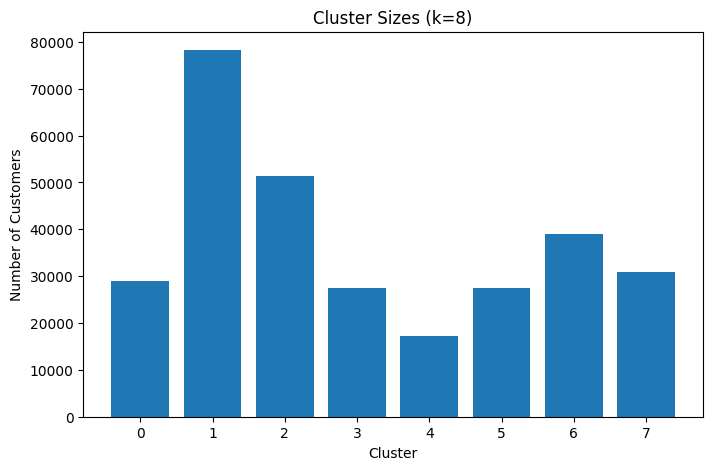

In [ ]:
import matplotlib.pyplot as plt

cluster_counts = df_clustered['Cluster'].value_counts().sort_index()

plt.figure(figsize=(8,5))
plt.bar(cluster_counts.index, cluster_counts.values)
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.title("Cluster Sizes (k=8)")
plt.show()

These findings indicate that the available features, particularly demographic variables such as age, do not strongly explain or predict customer spending behavior. As a result, predictive modeling was not suitable for addressing the research problem.

To better understand customer behavior, the analysis shifted to clustering techniques. K-Means clustering successfully identified distinct customer segments based on spending patterns. The results revealed clear differences between high-value, mid-value, and low-value customers, with significant variation observed even within similar age groups.

Overall, the findings suggest that customer behavior is better understood through segmentation rather than prediction. Businesses should therefore focus on identifying and targeting behavioral segments rather than relying on traditional demographic-based strategies. This approach enables more effective marketing, improved customer engagement, and enhanced revenue optimization.